# Chess Images Classification with Deep Learning

The primary objective of this project is to achieve the automated detection and classification of chess pieces by leveraging deep learning algorithms and multi-class image classification approaches.

<img src='https://a.espncdn.com/photo/2022/1120/r1093637_1296x729_16-9.jpg' width='750'> 

### Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2 
import tensorflow as tf
from sklearn.model_selection import train_test_split
import random
from keras.models import Sequential
from keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D, Dropout, BatchNormalization, Reshape
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
import logging
tf.get_logger().setLevel('ERROR')
logging.getLogger('absl').setLevel(logging.ERROR)

### EDA

In [6]:
img_path = tf.keras.utils.image_dataset_from_directory(
    '.',
    image_size=(224, 224),
    batch_size=32
)

Found 651 files belonging to 5 classes.


In [16]:
img_path = '.' 

img_list = []
label_list = []

for label in os.listdir(img_path):
    label_dir = os.path.join(img_path, label)
    
    if os.path.isdir(label_dir) and not label.startswith('.'):
        for img_name in os.listdir(label_dir):
            file_path = os.path.join(label_dir, img_name)
            
            img_list.append(file_path)
            label_list.append(label)

In [17]:
df = pd.DataFrame({"image_path": img_list,"label": label_list})

In [18]:
df.head()

,image_path,label
0,.\bishop\00000000_resized.jpg,bishop
1,.\bishop\00000002_resized.jpg,bishop
2,.\bishop\00000003_resized.jpg,bishop
3,.\bishop\00000004_resized.jpg,bishop
4,.\bishop\00000005_resized.jpg,bishop


In [19]:
df.tail()

,image_path,label
646,.\Rook\00000264_resized.jpg,Rook
647,.\Rook\00000265_resized.jpg,Rook
648,.\Rook\00000267_resized.jpg,Rook
649,.\Rook\00000276_resized.jpg,Rook
650,.\Rook\00000292_resized.jpg,Rook


In [20]:
img_path = '.'

labels = sorted([
    folder for folder in os.listdir(img_path)
    if os.path.isdir(os.path.join(img_path, folder))
])

print(labels)

['.ipynb_checkpoints', 'Queen', 'Rook', 'bishop', 'knight', 'pawn']


C:\Users\furka\AppData\Local\Temp\ipykernel_9632\3182711694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='viridis')


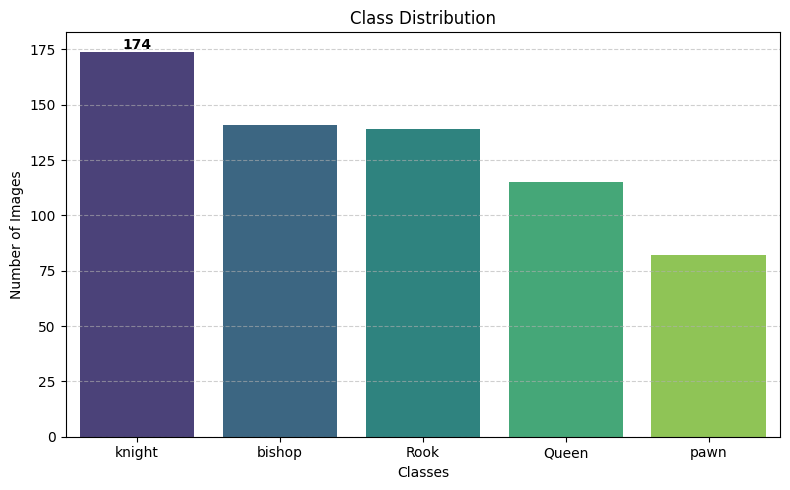

In [21]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='viridis')

ax.bar_label(ax.containers[0], fontweight='bold')

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

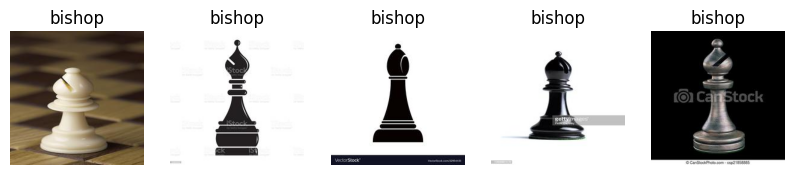

In [22]:
sample_df = df.head(5)

plt.figure(figsize=(10,4))

for i, row in enumerate(sample_df.itertuples()):
    img = cv2.imread(row.image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis("off")

plt.show()


#Shows the first 5 lines

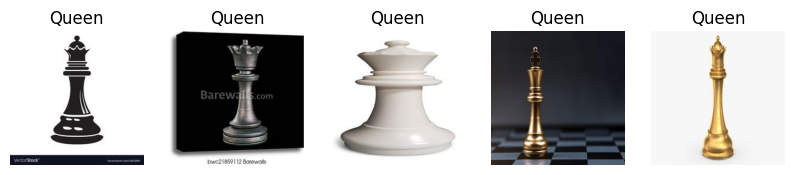

In [24]:
sample_df = df[df['label'] == 'Queen'].sample(5)

plt.figure(figsize=(10,4))

for i, row in enumerate(sample_df.itertuples()):
    img = cv2.imread(row.image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title("Queen")
    plt.axis("off")

plt.show()

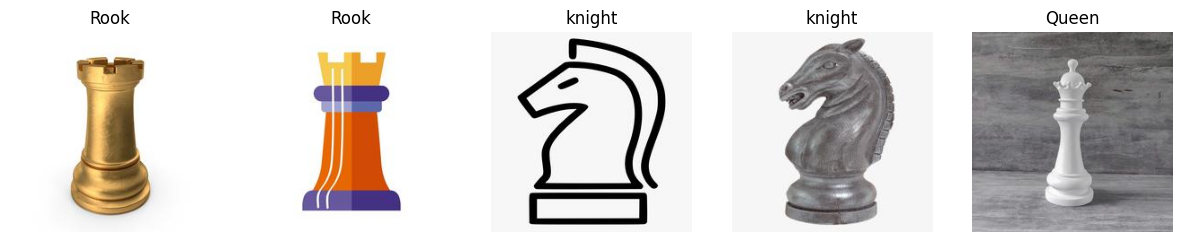

In [25]:
def show_random_images(df, n=5):
    plt.figure(figsize=(15, 5))

    rand_indices = random.sample(range(len(df)), n)
    
    for i, idx in enumerate(rand_indices):
        img_path = df.iloc[idx]['image_path']
        label = df.iloc[idx]['label']
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")
    plt.show()

show_random_images(df, 5)

### Data Preprocessing

In [26]:
#Fixed size + Normalisation
img_size = 224

def load_and_preprocess(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = img / 255.0
    return img

In [27]:
x = np.array([load_and_preprocess(p) for p in df['image_path']])
y = pd.get_dummies(df['label']).values

### Transfer Learning

In [28]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [29]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [37]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(len(df['label'].unique()), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [38]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

In [39]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(train_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32, class_mode='categorical')
val_gen = datagen.flow_from_dataframe(test_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32, class_mode='categorical')

Found 520 validated image filenames belonging to 5 classes.
Found 131 validated image filenames belonging to 5 classes.


In [40]:
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [41]:
history = model.fit(train_gen, validation_data=val_gen, epochs=15)

Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 832ms/step - accuracy: 0.2558 - loss: 1.8607 - val_accuracy: 0.4962 - val_loss: 1.3659
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 697ms/step - accuracy: 0.4000 - loss: 1.5679 - val_accuracy: 0.6031 - val_loss: 1.2076
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 722ms/step - accuracy: 0.4500 - loss: 1.3775 - val_accuracy: 0.6489 - val_loss: 1.0936
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 689ms/step - accuracy: 0.5385 - loss: 1.2340 - val_accuracy: 0.7099 - val_loss: 0.9968
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 697ms/step - accuracy: 0.5712 - loss: 1.1384 - val_accuracy: 0.7405 - val_loss: 0.9285
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 679ms/step - accuracy: 0.6115 - loss: 1.0651 - val_accuracy: 0.7786 - val_loss: 0.8723
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 707ms/step - accuracy: 0.6500 - loss: 0.9589 - val_accuracy: 0.7634 - val_loss: 0.8276
Epoch 8/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 678ms/step - accuracy: 0.6615 - loss: 0.9173 - val_accu

In [42]:
model.save('chess_model.keras')

In [43]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,751,825 (10.50 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 329,228 (1.26 MB)

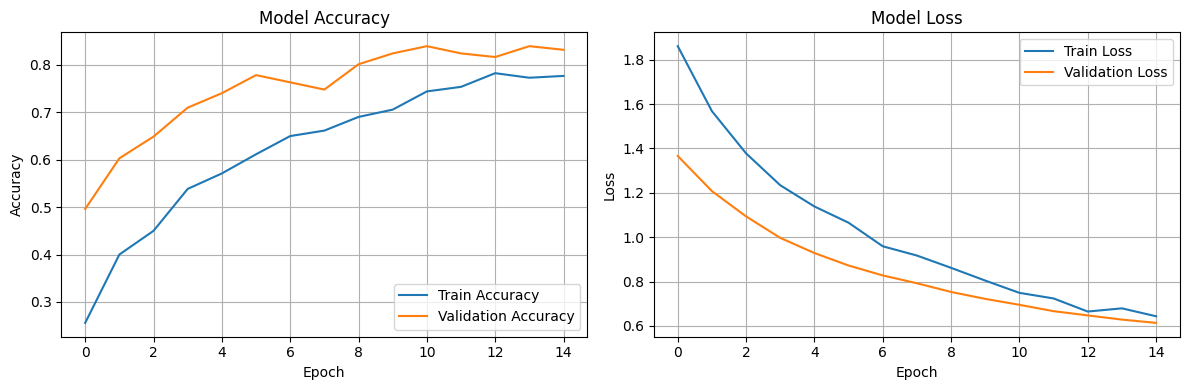

In [44]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Model TEST

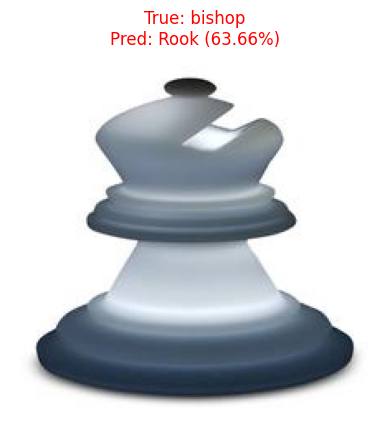

In [47]:
import random

def predict_random_test_image():

    random_row = df.sample(1).iloc[0]
    img_path = random_row['image_path']
    true_label = random_row['label']


    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_size, img_size))
    
    
    img_norm = img_resized / 255.0
    img_norm = np.expand_dims(img_norm, axis=0)


    pred = model.predict(img_norm, verbose=0)
    pred_idx = np.argmax(pred)
    pred_class = labels[pred_idx]
    confidence = np.max(pred) * 100

  
    plt.imshow(img_resized)

    title_color = 'green' if pred_class == true_label else 'red'
    
    plt.title(f"True: {true_label}\nPred: {pred_class} ({confidence:.2f}%)", color=title_color)
    plt.axis("off")
    plt.show()


predict_random_test_image()


#Test with a Single Image

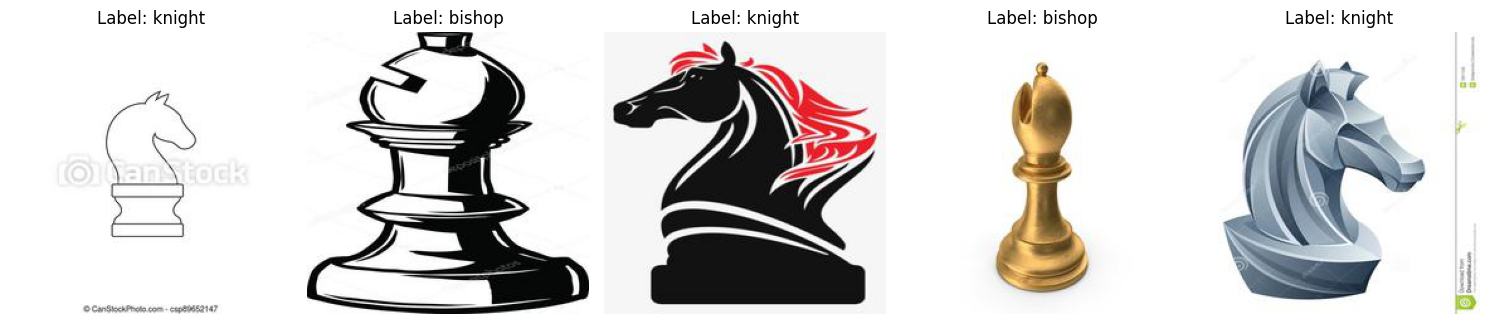

In [49]:
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

num_samples = 5
random_idxs = random.sample(range(len(test_df)), num_samples)

plt.figure(figsize=(15, 4))

for i, idx in enumerate(random_idxs):
    img_path = test_df.iloc[idx]['image_path']
    label = test_df.iloc[idx]['label']
    
    img = load_img(img_path, target_size=(224, 224))
    
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In conclusion, the developed deep learning model successfully classifies chess pieces with high accuracy, demonstrating the effectiveness of automated computer vision systems in object recognition.